In [1]:
!pip install joblib scikit-learn matplotlib seaborn pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

In [3]:
uploaded = files.upload()  # Upload migraine_data.csv
df = pd.read_csv("/content/migraine_data.csv")

Saving migraine_data.csv to migraine_data (1).csv


In [4]:
def detect_target_column(frame: pd.DataFrame):
    cols = frame.columns
    preferred = [c for c in cols if any(k in c.lower() for k in ["type", "migraine", "label", "target", "class"])]
    for c in preferred:
        uniq = frame[c].dropna().unique()
        if 2 <= len(uniq) <= 20:
            return c
    return None

In [5]:

target_col = detect_target_column(df)
y = df[target_col]
print("Detected target column:", target_col)

# Drop target + obvious IDs
drop_cols = [target_col]
id_like = [c for c in df.columns if any(k in c.lower() for k in ["id", "uid", "patient", "subject"])]
drop_cols.extend(id_like)
X = df.drop(columns=drop_cols)

# Split numeric & categorical
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]


Detected target column: Type


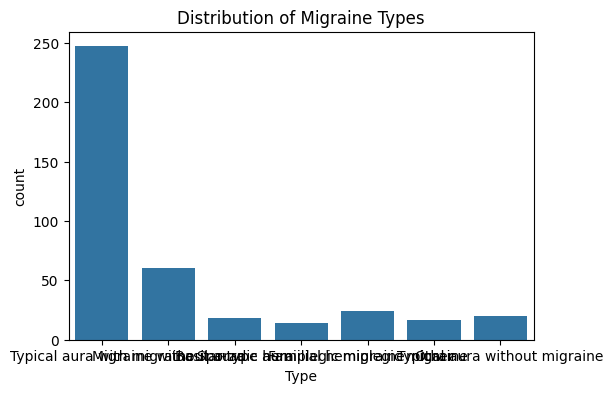

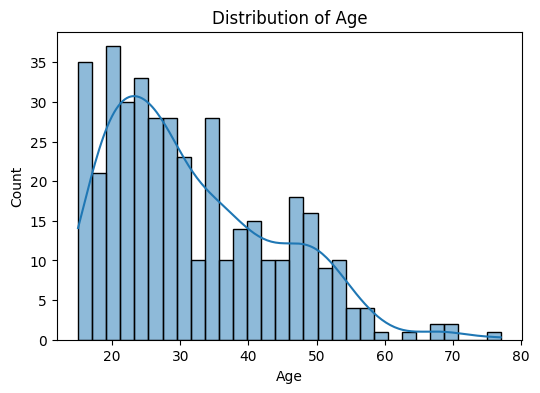

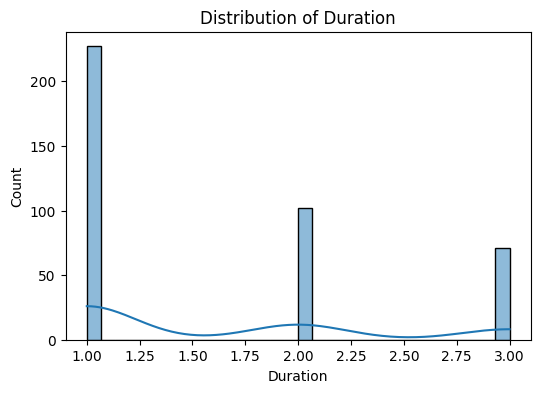

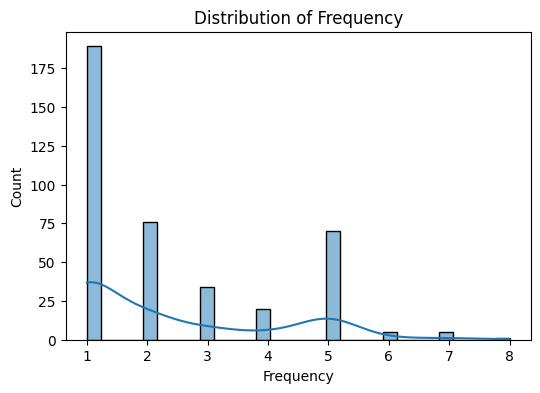

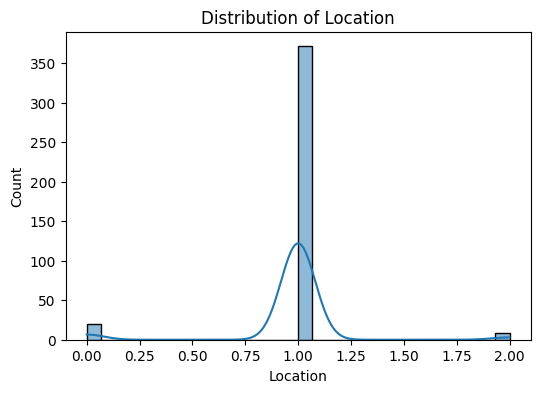

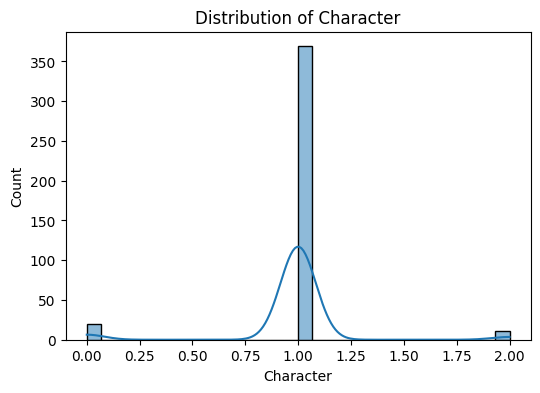

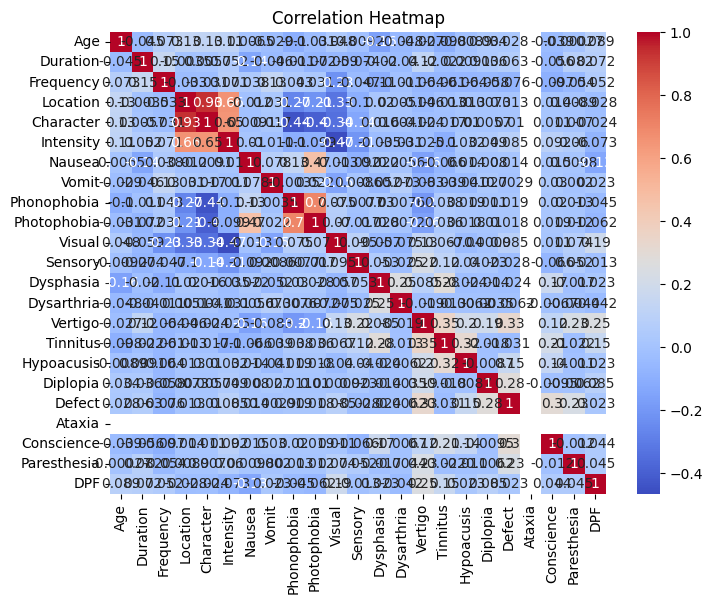

In [6]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribution of Migraine Types")
plt.show()

# Numeric feature distributions
for col in numeric_cols[:5]:
    plt.figure(figsize=(6,4))
    sns.histplot(X[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

# Correlation heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(8,6))
    corr = X[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()


Detected target column: Type
✅ Accuracy: 0.925
✅ F1 (macro): 0.873065823065823

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.60      0.75         5
           2       0.86      1.00      0.92        12
           3       1.00      0.67      0.80         3
           4       1.00      0.67      0.80         3
           5       0.94      0.96      0.95        49
           6       1.00      1.00      1.00         4

    accuracy                           0.93        80
   macro avg       0.94      0.84      0.87        80
weighted avg       0.93      0.93      0.92        80



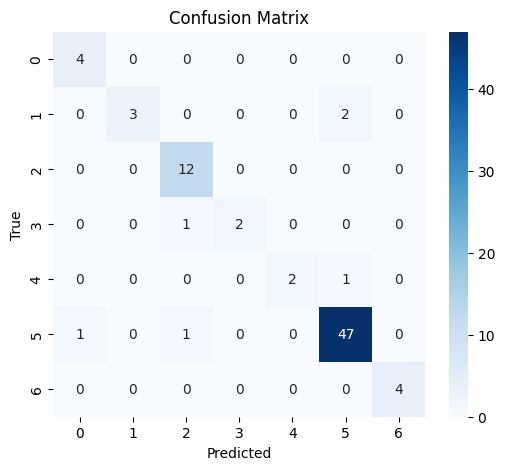

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
def detect_target_column(frame: pd.DataFrame):
    cols = frame.columns
    preferred = [c for c in cols if any(k in c.lower() for k in ["type", "migraine", "label", "target", "class"])]
    for c in preferred:
        uniq = frame[c].dropna().unique()
        if 2 <= len(uniq) <= 20:
            return c
    return None

target_col = detect_target_column(df)
le = LabelEncoder()
y = le.fit_transform(df[target_col])
print("Detected target column:", target_col)

# Drop target + IDs
drop_cols = [target_col]
id_like = [c for c in df.columns if any(k in c.lower() for k in ["id", "uid", "patient", "subject"])]
drop_cols.extend(id_like)
X = df.drop(columns=drop_cols)

# Split numeric & categorical
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

# ========================
# 5. Feature Reduction
# ========================
if numeric_cols:
    vt = VarianceThreshold(threshold=0.01)
    X_vt = vt.fit_transform(X[numeric_cols].fillna(0))
    reduced_num_cols = [c for i,c in enumerate(numeric_cols) if vt.get_support()[i]]
else:
    reduced_num_cols = []

if reduced_num_cols:
    selector = SelectKBest(score_func=f_classif, k=min(15, len(reduced_num_cols)))
    X_kbest = selector.fit_transform(X[reduced_num_cols].fillna(0), y)
    selected_features = [reduced_num_cols[i] for i in selector.get_support(indices=True)]
else:
    selected_features = []

final_features = selected_features + categorical_cols
X = X[final_features]

# ========================
# 6. Preprocessing & Model
# ========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [c for c in final_features if c in numeric_cols]),
        ("cat", categorical_transformer, [c for c in final_features if c in categorical_cols]),
    ]
)

# XGBoost classifier tuned for high accuracy
clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="mlogloss"
)

pipe = Pipeline(steps=[("preprocess", preprocess),
                      ("clf", clf)])

# ========================
# 7. Train/Test Split
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ========================
# 8. Train Model
# ========================
pipe.fit(X_train, y_train)

# ========================
# 9. Evaluation
# ========================
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("✅ Accuracy:", acc)
print("✅ F1 (macro):", f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ========================
# 10. Save & Download Model
# ========================
joblib.dump({"pipeline": pipe, "label_encoder": le}, "migraine_type_model.joblib")
files.download("migraine_type_model.joblib")
